> **NOTA:** El siguiente notebook corresponde a una versión anterior del proyecto. Debido a inconsistencias en los datos, se optó por utilizar otro dataset para aplicar la consigna del SPLIT 3. Sin embargo, se conserva este notebook para dejar constancia de la información contenida.




# 📧 Análisis de Interacción en Campaña de Email Marketing  

El equipo de Marketing de la compañía utiliza campañas de mailing para interactuar con clientes potenciales. Se ha consultado al equipo de Data Science para identificar segmentos de clientes según su interacción con los correos electrónicos.  

Las preguntas clave a responder son:  
✅ ¿Existen grupos de usuarios con comportamientos similares?  
✅ ¿Se pueden detectar patrones útiles para la segmentación?  
✅ ¿Es posible crear nuevos atributos y entrenar un modelo de segmentación?  

El objetivo final es analizar y caracterizar los segmentos identificados, describiendo sus cualidades particulares.  

---

## 📊 Descripción del Dataset  

Se dispone de un conjunto de datos que registra la interacción de los usuarios con los correos enviados en una campaña de email marketing. Cada usuario está identificado de forma única por la columna `Id`.  

### 🔹 **Métricas registradas**  
- ✉️ **`send`**: Número total de correos electrónicos enviados al usuario.  
- 🚫 **`bounce`**: Cantidad de correos que no llegaron al destinatario.  
- 👀 **`open`**: Número de correos abiertos por el usuario.  
- 🔗 **`click`**: Cantidad de veces que el usuario hizo clic en enlaces dentro del correo.  

📌 **Nota:** Se espera que la columna `Total` represente la suma de `send`, `bounce`, `open` y `click`, pero se debe verificar su consistencia.  

### 🔹 **Información adicional**  
- 🛒 **`Comprador`**: Indica si el usuario realizó una compra.  
  - ✅ `1`: Realizó una compra.  
  - ❌ `0`: No realizó una compra.  
- ⏰ **`hour`**: Hora promedio de interacción con los correos.  
- 📅 **`day_of_week`**: Día de la semana en que ocurrió la interacción (`0 = domingo`, `6 = sábado`).  





In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [212]:


# Carga el archivo Excel
df = pd.read_excel("clustering_mailing.xlsx", engine="openpyxl")

print(df.head(5))  # Muestra las primeras 5 filas

# Ver cuántas filas tiene el DataFrame
num_filas = df.shape[0]

print(f"El DataFrame tiene {num_filas} filas.")



        Id  send  bounce  open  click  Total  Comprador       hour  \
0  2044163     4       0     0      0      4          0  17.000000   
1   633731     1       0     0      0      1          0  21.000000   
2  1537126     4       0     0      0      4          0  17.000000   
3  1960135     3       0     0      0      3          0  15.333333   
4  1004992     8       0     1      0     10          1  18.222222   

   day_of_week  
0     3.500000  
1     4.000000  
2     3.500000  
3     3.333333  
4     2.000000  
El DataFrame tiene 212292 filas.


In [213]:
# Mostrar información general del DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212292 entries, 0 to 212291
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Id           212292 non-null  int64  
 1   send         212292 non-null  int64  
 2   bounce       212292 non-null  int64  
 3   open         212292 non-null  int64  
 4   click        212292 non-null  int64  
 5   Total        212292 non-null  int64  
 6   Comprador    212292 non-null  int64  
 7   hour         212292 non-null  float64
 8   day_of_week  212292 non-null  float64
dtypes: float64(2), int64(7)
memory usage: 14.6 MB
None


basicamente, en este dataset se encuentran muchas inconsistencias, como por ejemplo la columna "total" la cual tiene en ciertas columnas valores que tienen por ejemplo 9 mails enviados , luego las demas tiene nulas y el total 10, lo cual expresa que el dataset presenta complicaciones de consistencia en los datos, por ejemplo la columna a continuacion: 


In [214]:
fila_4 = df.iloc[4].astype(int)  # Selecciona la fila 6 y convierte a enteros
print(fila_4)


Id             1004992
send                 8
bounce               0
open                 1
click                0
Total               10
Comprador            1
hour                18
day_of_week          2
Name: 4, dtype: int64


In [215]:
# Cargar el archivo
df = pd.read_excel("clustering_mailing.xlsx", engine="openpyxl")

# Contar los casos donde se cumple la condición
casos_cumplen = (df["Total"] == df["send"] + df["bounce"] + df["open"]).sum()

# Mostrar el resultado
print(f"Cantidad de casos que cumplen la condición: {casos_cumplen}")

casos_no_cumplen = (df["Total"] != df["send"] + df["bounce"] + df["open"]).sum()

# Mostrar el resultado
print(f"Cantidad de casos que NO cumplen la condición: {casos_no_cumplen}")



Cantidad de casos que cumplen la condición: 191200
Cantidad de casos que NO cumplen la condición: 21092


Por estas inconsistencias se procedio a trabajar con total sumatoria, los cuales trabajan sobre la sumatoria de los valros anteriores, dando como resultado los siguientes valorees: 

Id: Identificador único de cada usuario o destinatario.

send: Cantidad de correos electrónicos enviados a este usuario.

bounce: Correos rebotados (no llegaron al destinatario).

open: Número de correos abiertos por el usuario.

click: Número de veces que el usuario hizo clic en un enlace dentro del correo.

Total: Suma total de interacciones del usuario con los correos (podría ser la suma de send, open y click).

Comprador: Indica si el usuario realizó una compra (0 = no compró, 1 = compró).

hour: Hora en que el usuario interactuó con los correos (posiblemente promedio de varias interacciones).

day_of_week: Día de la semana en que ocurrió la interacción (puede estar en formato numérico, donde 0 = domingo, 6 = sábado).

intuitivamente la suma de "send" "bounce" "open" y click debe dar el total



In [216]:


# Filtrar los casos que cumplen con la condición
filtro = (df["Comprador"] == 1) & (df["open"] == 0) & (df["click"] == 0)

# Contar la cantidad de casos que cumplen la condición
cantidad_casos = filtro.sum()

# Mostrar el resultado
print(f"Cantidad de casos que cumplen la condición: {cantidad_casos}")


Cantidad de casos que cumplen la condición: 96110


esta condicion NO tiene sentido ya que , que indica que ese usuario COMPRO pero nunca clickeo para ir a enlaces de compra lo cual no tiene sentido., ademas no puedo tener mas abiertos que los emails enviados. si me enviaron 8 mails, como maximo abri 8. LO mismo para cantidad de veces click a la enviados, si tengo 8 mails, abro max 8. como compro si no abrio el mail y no clickeo?

-hacer teoria del codo 
- hacer grafico en 3d (3 variables), ver quienes compra, quienes compra y abre pocos mails y otro grupo que abre mucho pero no compra mucho
- considerar variables de "open" , "click" y "compro o no"


In [217]:
# Verificar si hay valores distintos de 0 y 1 en la columna "Comprador"
valores_unicos = df["Comprador"].unique()
valores_distintos = [val for val in valores_unicos if val not in [0, 1]]

if valores_distintos:
    print("Existen valores distintos de 0 y 1 en la columna 'Comprador':", valores_distintos)
else:
    print("Todos los valores en la columna 'Comprador' son 0 o 1.")

Todos los valores en la columna 'Comprador' son 0 o 1.


In [218]:
df_corregido = df.copy()

# Cantidad total de filas
total_filas = len(df)

# Verificar si hay casos donde "open" > "send"
inconsistencia_abiertos = df[df["open"] > df["send"]]

# Verificar si hay casos donde "click" > "open"
inconsistencia_clicks = df[df["click"] > df["open"]]

# Verificar si hay casos donde "Comprador" == 1 pero no hubo aperturas ni clics
inconsistencia_compras = df[(df["Comprador"] == 1) & ((df["open"] == 0) | (df["click"] == 0))]

# Verificar si "Total" no coincide con la suma de "send", "bounce", "open" y "click"
inconsistencia_total = df[df["Total"] != (df["send"] + df["bounce"] + df["open"] + df["click"])]

# Unir todas las filas con inconsistencias en un solo DataFrame (eliminar duplicados)
inconsistencias_completas = pd.concat(
    [inconsistencia_abiertos, inconsistencia_clicks, inconsistencia_compras, inconsistencia_total]
).drop_duplicates()

# Cantidad de filas con al menos una inconsistencia
total_inconsistencias = len(inconsistencias_completas)

# Calcular el porcentaje de filas con inconsistencias
porcentaje_inconsistencias = (total_inconsistencias / total_filas) * 100

# Mostrar los resultados
print(f"Inconsistencias donde 'open' es mayor a 'send': {len(inconsistencia_abiertos)} filas")
print(f"Inconsistencias donde 'click' es mayor a 'open': {len(inconsistencia_clicks)} filas")
print(f"Inconsistencias donde 'Comprador' es 1 pero no hubo interacciones previas: {len(inconsistencia_compras)} filas")
print(f"Inconsistencias en la columna 'Total': {len(inconsistencia_total)} filas")
print(f"Total de filas con al menos una inconsistencia: {total_inconsistencias} de {total_filas} ({porcentaje_inconsistencias:.2f}%)")



Inconsistencias donde 'open' es mayor a 'send': 5106 filas
Inconsistencias donde 'click' es mayor a 'open': 1863 filas
Inconsistencias donde 'Comprador' es 1 pero no hubo interacciones previas: 125368 filas
Inconsistencias en la columna 'Total': 15283 filas
Total de filas con al menos una inconsistencia: 135428 de 212292 (63.79%)


In [219]:

# Filtrar y descartar esas filas
df_corregido = df[~df.index.isin(inconsistencia_abiertos.index)]  # Descartar casos donde open > send
df_corregido = df_corregido[~df_corregido.index.isin(inconsistencia_clicks.index)]  # Descartar casos donde click > open

# Número de filas descartadas
filas_descartadas = len(inconsistencia_abiertos) + len(inconsistencia_clicks)

# Número de filas que quedan
filas_quedan = len(df_corregido)

print(f"Filas descartadas: {filas_descartadas}")
print(f"Filas restantes: {filas_quedan}")

# Asegurarse de que los índices de inconsistencia_compras sean compatibles con df_corregido
df_corregido.loc[df_corregido.index.isin(inconsistencia_compras.index), "open"] = 1
df_corregido.loc[df_corregido.index.isin(inconsistencia_compras.index), "click"] = 1



Filas descartadas: 6969
Filas restantes: 205440


Las inconsistencia de tipo III (comprador no click) es absurda, por lo cal es aquellos casos se va a harcodear un 1 en click y open

In [220]:
# CHECKEOOOOOOOOOO
# Filtrar los casos donde 'Comprador' == 1, 'open' == 0 y 'click' == 0
inconsistencias_compras = df_corregido[(df_corregido["Comprador"] == 1) & (df_corregido["open"] == 0) & (df_corregido["click"] == 0)]

# Filtrar los casos donde 'open' > 'send'
inconsistencias_abiertos = df_corregido[df_corregido["open"] > df_corregido["send"]]

# Filtrar los casos donde 'click' > 'open'
inconsistencias_clicks = df_corregido[df_corregido["click"] > df_corregido["open"]]

# Verificar si hay filas con inconsistencias
print(f"Inconsistencias donde 'Comprador' == 1 pero no hubo interacciones previas: {len(inconsistencias_compras)} filas")
print(f"Inconsistencias donde 'open' > 'send': {len(inconsistencias_abiertos)} filas")
print(f"Inconsistencias donde 'click' > 'open': {len(inconsistencias_clicks)} filas")



Inconsistencias donde 'Comprador' == 1 pero no hubo interacciones previas: 0 filas
Inconsistencias donde 'open' > 'send': 0 filas
Inconsistencias donde 'click' > 'open': 0 filas



## 🎯 **Clustering!: K-Means en la Segmentación de Usuarios**  

El objetivo de este algoritmo es encontrar grupos en los datos, con el número de grupos representados por la variable K, *encontrar el k optimo!*.

El algoritmo funciona de manera iterativa para asignar cada punto de datos a uno de los grupos K en función de las características que se proporcionan.

El objetivo es **segmentar a los usuarios** según su comportamiento en la campaña de email marketing mediante el algoritmo de clustering **K-Means**. Para ello, se tomarán en cuenta las interacciones de los usuarios con los correos electrónicos enviados, buscando agruparlos en distintos perfiles de comportamiento.  

### 🔹 **Justificación del uso de K-Means**  
- Permite encontrar **patrones de comportamiento** en los datos sin necesidad de etiquetas previas.  
- Es eficiente en términos computacionales para conjuntos de datos de tamaño moderado.  
- Ayuda a descubrir **grupos naturales de usuarios**, facilitando la personalización de futuras estrategias de marketing.  

### 🔹 **Variables a utilizar para el clustering**  
Las siguientes métricas serán utilizadas para definir los grupos de usuarios:  
1. ✉️ **`send`**: Número total de correos enviados.  
2. 🚫 **`bounce`**: Correos que no llegaron al destinatario.  
3. 👀 **`open`**: Correos abiertos por el usuario.  
4. 🔗 **`click`**: Cantidad de clics en enlaces dentro del correo.  
5. ⏰ **`hour`**: Hora promedio de interacción.  
6. 📅 **`day_of_week`**: Día de la semana con mayor actividad.  

📌 **Nota:** Se normalizarán las variables para evitar que escalas diferentes afecten el clustering.  

### 🔹 **Proceso de Implementación**  
1. **Preprocesamiento de datos**:  
   - Verificar y limpiar datos faltantes o inconsistencias en la columna `Total`.  
   - Normalizar las variables para que tengan una escala comparable.  
2. **Elección del número óptimo de clusters (`k`)**:  
   - Utilizar el método del **codo (Elbow Method)** o **silhouette score** para determinar el número adecuado de grupos.  
3. **Aplicación del algoritmo K-Means**:  
   - Ejecutar K-Means sobre las variables seleccionadas.  
   - Evaluar la calidad de los clusters obtenidos.  
4. **Interpretación y caracterización de los segmentos**:  
   - Analizar los grupos y describir sus características.  
   - Evaluar si ciertos clusters tienen mayor relación con la conversión (`Comprador`).  

### 🔹 **Resultados esperados**  
- Identificación de **segmentos de usuarios** con diferentes niveles de interacción.  
- Posible detección de grupos con alta probabilidad de conversión.  
- Insights para mejorar la personalización de futuras campañas de email marketing.  


In [221]:
df_corregido.shape # 9 col x 20544 filas

(205440, 9)

In [222]:
df_corregido2 = df_corregido[["send", "open", "Comprador"]]
df_corregido2.shape # 9 col x 20544 filas

X = df_corregido2[["send", "open", "Comprador"]].values #lo hago array


In [223]:
X

array([[4, 0, 0],
       [1, 0, 0],
       [4, 0, 0],
       ...,
       [1, 0, 0],
       [5, 1, 1],
       [9, 9, 1]])

El método del codo se usa para determinar el número óptimo de clusters en K-Means. 

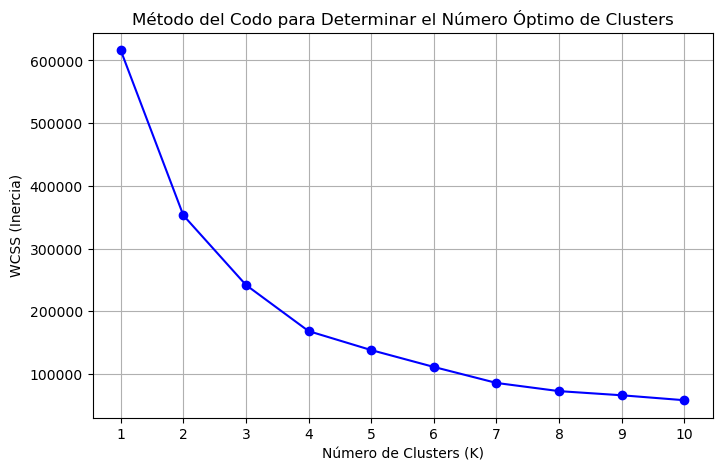

In [224]:
# Estandarizar los datos para mejorar la precisión de K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lista para almacenar la suma de los errores cuadrados dentro del cluster (WCSS)
wcss = []      

# Probar con diferentes números de clusters (K)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # Guardar la inercia

# Graficar el método del codo
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Método del Codo para Determinar el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Inercia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

En el gráfico del método del codo, el punto óptimo de \( K \) se elige donde la inercia (WCSS) deja de disminuir significativamente y la curva se "dobla", formando un codo. En este caso, el codo parece estar en  \( K = 4 \), ya que después de este punto la reducción en WCSS es menos pronunciada.


In [225]:
# Crear el modelo k-Means para 4 grupos
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)

# Ajustar el modelo y predecir las etiquetas de los clusters
y_kmeans = kmeans.fit_predict(X)

In [226]:
y_kmeans

array([0, 0, 0, ..., 0, 3, 1], dtype=int32)

In [227]:
df_corregido['prediccion'] = y_kmeans

df_corregido


,Id,send,bounce,open,click,Total,Comprador,hour,day_of_week,prediccion
0,2044163,4,0,0,0,4,0,17.000000,3.500000,0
1,633731,1,0,0,0,1,0,21.000000,4.000000,0
2,1537126,4,0,0,0,4,0,17.000000,3.500000,0
3,1960135,3,0,0,0,3,0,15.333333,3.333333,0
4,1004992,8,0,1,1,10,1,18.222222,2.000000,3
...,...,...,...,...,...,...,...,...,...,...
212287,1996785,4,0,0,0,4,0,17.000000,3.500000,0
212288,1485221,1,1,0,0,2,0,19.000000,4.000000,0
212289,1521848,1,0,0,0,1,0,19.000000,4.000000,0
212290,2001602,5,0,1,1,5,1,20.200000,1.400000,3


In [228]:
# datos para cada grupo!

Grupo0 = df_corregido[df_corregido['prediccion']==0]
Grupo1 = df_corregido[df_corregido['prediccion']==1]
Grupo2 = df_corregido[df_corregido['prediccion']==2]
Grupo3 = df_corregido[df_corregido['prediccion']==3]

In [229]:
Grupo0

,Id,send,bounce,open,click,Total,Comprador,hour,day_of_week,prediccion
0,2044163,4,0,0,0,4,0,17.000000,3.500000,0
1,633731,1,0,0,0,1,0,21.000000,4.000000,0
2,1537126,4,0,0,0,4,0,17.000000,3.500000,0
3,1960135,3,0,0,0,3,0,15.333333,3.333333,0
5,1598931,2,0,1,1,2,1,17.500000,5.000000,0
...,...,...,...,...,...,...,...,...,...,...
212284,936128,2,2,1,1,4,1,21.500000,3.000000,0
212285,418837,1,0,1,1,2,1,16.000000,3.500000,0
212287,1996785,4,0,0,0,4,0,17.000000,3.500000,0
212288,1485221,1,1,0,0,2,0,19.000000,4.000000,0


In [230]:
Grupo1

,Id,send,bounce,open,click,Total,Comprador,hour,day_of_week,prediccion
17,551080,17,0,1,1,18,1,19.500000,2.611111,1
62,124422,14,0,1,1,15,1,19.666667,2.400000,1
67,612042,10,0,1,1,12,1,19.083333,2.000000,1
68,747460,11,0,1,1,11,1,20.545455,1.363636,1
80,931226,10,0,1,1,12,1,18.363636,2.272727,1
...,...,...,...,...,...,...,...,...,...,...
212260,89493,9,0,1,1,9,1,19.333333,1.666667,1
212267,478547,9,0,0,0,9,0,19.111111,2.555556,1
212279,475906,11,0,1,1,12,1,18.000000,2.454545,1
212286,538508,9,0,1,1,9,1,20.555556,2.555556,1


In [231]:
Grupo2

,Id,send,bounce,open,click,Total,Comprador,hour,day_of_week,prediccion
20,352644,18,0,1,1,18,1,20.333333,2.277778,2
171,667710,21,0,1,1,22,1,20.136364,2.863636,2
184,1854488,24,0,1,1,24,1,20.291667,2.458333,2
200,466138,22,0,1,1,24,1,18.416667,3.041667,2
227,420099,35,0,1,1,36,1,19.114286,2.571429,2
...,...,...,...,...,...,...,...,...,...,...
212182,1414981,18,0,1,1,24,1,19.000000,3.304348,2
212185,251288,21,0,1,1,25,1,17.375000,2.583333,2
212191,65507,17,0,10,2,32,0,14.689655,1.931034,2
212209,73559,26,0,11,2,41,0,15.589744,2.461538,2


In [232]:
Grupo3

,Id,send,bounce,open,click,Total,Comprador,hour,day_of_week,prediccion
4,1004992,8,0,1,1,10,1,18.222222,2.000000,3
7,34136,5,0,5,2,12,1,17.666667,2.000000,3
9,41994,7,0,7,2,16,0,9.500000,0.687500,3
14,1332576,5,0,1,0,6,0,16.166667,2.666667,3
18,928624,7,0,1,1,7,1,20.428571,1.857143,3
...,...,...,...,...,...,...,...,...,...,...
212271,1359561,7,0,1,1,7,1,18.571429,3.000000,3
212272,915509,5,0,1,1,5,1,20.200000,1.400000,3
212275,1939889,5,0,0,0,5,0,17.400000,3.600000,3
212278,489608,7,0,1,1,7,1,18.571429,3.857143,3


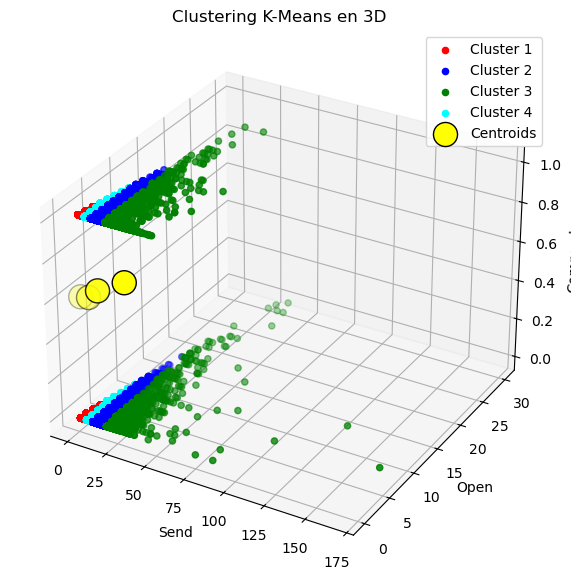

In [233]:

# Crear la figura en 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos con colores según su cluster
ax.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], X[y_kmeans == 0, 2], c='red', label='Cluster 1')
ax.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], X[y_kmeans == 1, 2], c='blue', label='Cluster 2')
ax.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], X[y_kmeans == 2, 2], c='green', label='Cluster 3')
ax.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], X[y_kmeans == 3, 2], c='cyan', label='Cluster 4')

# Graficar los centroides
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], 
           s=300, c='yellow', label='Centroids', edgecolors='black')

# Etiquetas de los ejes
ax.set_xlabel("Send")
ax.set_ylabel("Open")
ax.set_zlabel("Comprador")
ax.set_title("Clustering K-Means en 3D")

plt.legend()
plt.show()
